# Taller 2 - Parte 1
## Comparación de Modelos Supervisados (Random Forest, SVM, kNN)

In [114]:
# Librerías 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Utilidades
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

In [62]:
# Matriz de confusión (Estética)
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix", labels=None):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels, yticklabels=labels, cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


In [ ]:
# Dataset 1: Iris
iris = pd.read_csv("iris.csv")
print("Iris dataset:")
print(iris.head(), "\n")

# Dataset 2: Diabetes
diabetes = pd.read_csv("diabetes.csv")
print("Diabetes dataset:")
print(diabetes.head(), "\n")

Iris dataset:
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa 

Diabetes dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627

## División en train/test

In [42]:
# Dataset 1: Iris
# Features
X_iris = iris.drop(["Id", "Species"], axis=1)
y_iris = iris["Species"]

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print("Iris -> Train shape:", X_train_iris.shape, " Test shape:", X_test_iris.shape)

# Dataset 2: Diabetes
# Features
X_db = diabetes.drop("Outcome", axis=1)
y_db = diabetes["Outcome"]

X_train_db, X_test_db, y_train_db, y_test_db = train_test_split(
    X_db, y_db, test_size=0.2, random_state=42, stratify=y_db
)

print("Diabetes -> Train shape:", X_train_db.shape, " Test shape:", X_test_db.shape)


Iris -> Train shape: (120, 4)  Test shape: (30, 4)
Diabetes -> Train shape: (614, 8)  Test shape: (154, 8)


## Cross-Validation

In [110]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}

# Dataset Iris
print("\nCross-Validation - Iris Dataset")
for name, model in models.items():
    scores = cross_val_score(model, X_iris, y_iris, cv=5) 
    print(f"{name}: {scores.mean():.4f}")

# Dataset Diabetes
print("\nCross-Validation - Diabetes Dataset")
for name, model in models.items():
    scores = cross_val_score(model, X_db, y_db, cv=5)
    print(f"{name}: {scores.mean():.4f}")


Cross-Validation - Iris Dataset
Random Forest: 0.9667
kNN: 0.9733
SVM: 0.9667

Cross-Validation - Diabetes Dataset
Random Forest: 0.7670
kNN: 0.7240
SVM: 0.7591


# Modelos

## Random Forest

Random Forest - Iris
Accuracy: 0.9

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



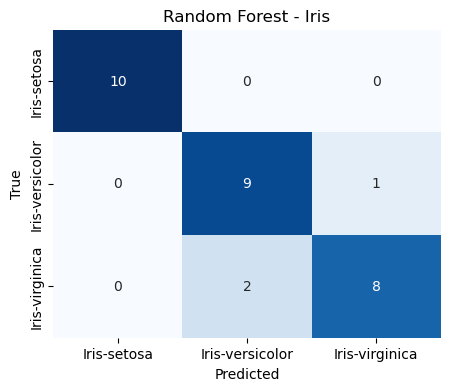

In [80]:
# Random Forest - Iris

rf_iris = RandomForestClassifier(n_estimators=100, random_state=42)
rf_iris.fit(X_train_iris, y_train_iris)

# Predicciones
y_pred_rf_iris = rf_iris.predict(X_test_iris)

# Evaluación
print("Random Forest - Iris")
print("Accuracy:", accuracy_score(y_test_iris, y_pred_rf_iris))
print("\nClassification Report:\n", classification_report(y_test_iris, y_pred_rf_iris))
plot_conf_matrix(y_test_iris, y_pred_rf_iris, 
                 title="Random Forest - Iris", 
                 labels=rf_iris.classes_)

Random Forest - Diabetes
Accuracy: 0.7597402597402597

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



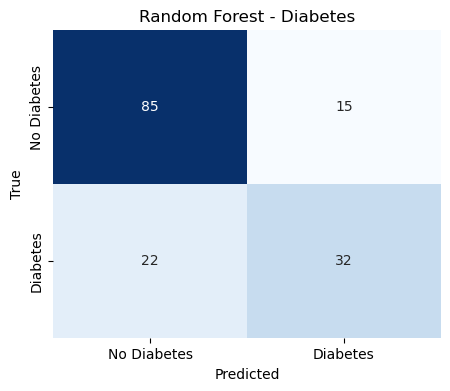

In [ ]:
# Random Forest - Diabetes

rf_db = RandomForestClassifier(n_estimators=100, random_state=42)
rf_db.fit(X_train_db, y_train_db)

# Predicciones
y_pred_rf_db = rf_db.predict(X_test_db)

# Evaluación
print("Random Forest - Diabetes")
print("Accuracy:", accuracy_score(y_test_db, y_pred_rf_db))
print("\nClassification Report:\n", classification_report(y_test_db, y_pred_rf_db))
plot_conf_matrix(y_test_db, y_pred_rf_db, 
                 title="Random Forest - Diabetes", 
                 labels=["No Diabetes", "Diabetes"])


## KNN

kNN - Iris
Accuracy: 0.9333333333333333

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30



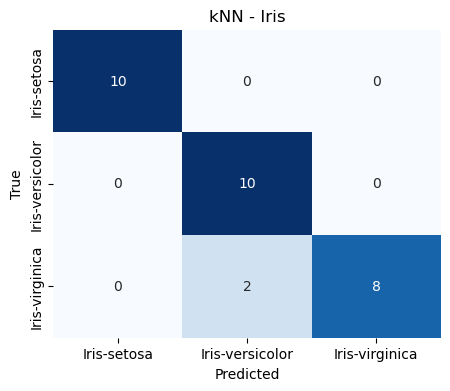

In [84]:
# kNN - Iris

knn_iris = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_iris.fit(X_train_iris, y_train_iris)

# Predicciones
y_pred_knn_iris = knn_iris.predict(X_test_iris)

# Evaluación
print("kNN - Iris")
print("Accuracy:", accuracy_score(y_test_iris, y_pred_knn_iris))
print("\nClassification Report:\n", classification_report(y_test_iris, y_pred_knn_iris))
plot_conf_matrix(y_test_iris, y_pred_knn_iris, 
                 title="kNN - Iris", 
                 labels=iris["Species"].unique())


kNN - Diabetes
Accuracy: 0.7012987012987013

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



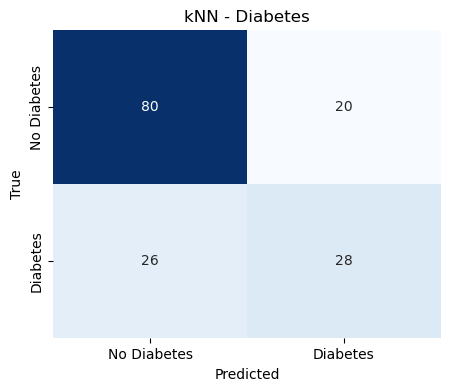

In [95]:
# kNN - Diabetes

knn_db = Pipeline([
    ("scaler", StandardScaler()), 
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

# Entrenamiento
knn_db.fit(X_train_db, y_train_db)

# Predicciones
y_pred_knn_db = knn_db.predict(X_test_db)

# Evaluación
print("kNN - Diabetes")
print("Accuracy:", accuracy_score(y_test_db, y_pred_knn_db))
print("\nClassification Report:\n", classification_report(y_test_db, y_pred_knn_db))
plot_conf_matrix(
    y_test_db, y_pred_knn_db,
    title="kNN - Diabetes",
    labels=["No Diabetes", "Diabetes"]
)





## SVM

SVM - Iris
Accuracy: 0.9666666666666667

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



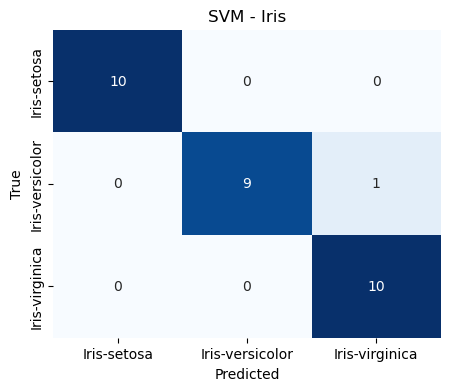

In [101]:
# SVM - Iris

svm_iris = Pipeline([
    ("scaler", StandardScaler()), 
    ("svm", SVC(kernel="rbf", C=1, gamma="scale"))  
])

svm_iris.fit(X_train_iris, y_train_iris)

# Predicciones
y_pred_svm_iris = svm_iris.predict(X_test_iris)

# Evaluación
print("SVM - Iris")
print("Accuracy:", accuracy_score(y_test_iris, y_pred_svm_iris))
print("\nClassification Report:\n", classification_report(y_test_iris, y_pred_svm_iris))
plot_conf_matrix(y_test_iris, y_pred_svm_iris, 
                 title="SVM - Iris", 
                 labels=iris["Species"].unique())


SVM - Diabetes
Accuracy: 0.7532467532467533

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



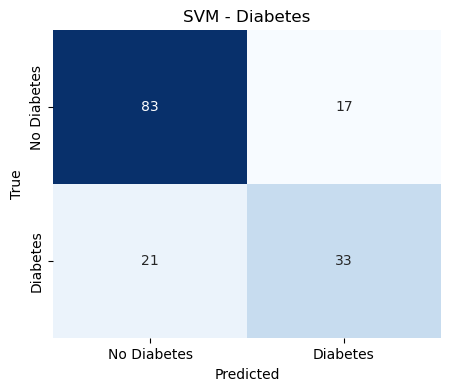

In [118]:
# SVM - Diabetes

svm_db = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])
svm_db.fit(X_train_db, y_train_db)

# Predicciones
y_pred_svm_db = svm_db.predict(X_test_db)

# Evaluación
print("SVM - Diabetes")
print("Accuracy:", accuracy_score(y_test_db, y_pred_svm_db))
print("\nClassification Report:\n", classification_report(y_test_db, y_pred_svm_db))
plot_conf_matrix(
    y_test_db, y_pred_svm_db,
    title="SVM - Diabetes",
    labels=["No Diabetes", "Diabetes"]
)



# Conclusiones

### ¿Qué se hizo?

En el taller se implementó un flujo completo de aprendizaje supervisado utilizando dos datasets (Iris y Diabetes) y tres clasificadores (Random Forest, KNN y SVM).
Se realizó la división de los datos en entrenamiento y prueba, además de la validación cruzada para evaluar la robustez de los modelos.

### Los resultados mostraron que:

En el dataset de Iris, todos los modelos alcanzaron un desempeño muy alto, con accuracies entre 0.90 y 0.97. 
En el dataset de Diabetes, los resultados fueron más bajos (0.70 – 0.77), reflejando la diferencia entre un dataset más limpio como el de Iris a comparación de de uno más complejo como el del diabetes.

SVM y kNN se benefician de la normalización (StandardScaler), mientras que Random Forest no la necesita.

Las matrices de confusión permitieron identificar qué clases fueron mejor clasificadas. En Iris casi todas las especies fueron correctamente predichas, mientras que en Diabetes hubo mayor confusión entre las clases “Diabetes” y “No Diabetes”.

### En general

Random Forest es un buen modelo y balancea precisión con robustez.

kNN puede alcanzar buenos resultados en datasets simples como el de Iris, pero pierde rendimiento en problemas más complejos como el de Diabetes.

SVM logra un excelente rendimiento en Iris y decente en Diabetes, aunque su desempeño depende fuertemente de la elección de hiperparámetros y la escala de los datos.

# Preguntas

## What happens to the performance of kNN and SVM if you skip the feature scaling step?

Ambos modelos (KNN y SVM) son muy sensibles a la escala de las variables:

En kNN, las distancias entre puntos dependen de las magnitudes de las caracteristicas (Features), entonces si una característica tiene valores mucho más grandes que otra, dominará el cálculo de la distancia, haciendo que el modelo clasifique mal.

En SVM, la frontera de decisión también depende de la magnitud de los atributos, así que si no se escala, el hiperplano puede quedar sesgado hacia las variables con valores más grandes, y eso afectaría bastante la precisión ppues la reduciría.

Entonces en los 2 datasets que utilizamos (Iris y Diabetes), es necesario aplicar el StandardScaler para que no diminuya enormemente el accuracy de kNN y SVM


## Which model was the fastest to train?

In [115]:
# kNN
start = time.perf_counter()
knn = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))])
knn.fit(X_train_db, y_train_db)
end = time.perf_counter()
print(f"kNN training time: {end - start:.6f} seconds")

# SVM
start = time.perf_counter()
svm = Pipeline([("scaler", StandardScaler()), ("svm", SVC())])
svm.fit(X_train_db, y_train_db)
end = time.perf_counter()
print(f"SVM training time: {end - start:.6f} seconds")

# Random Forest
start = time.perf_counter()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_db, y_train_db)
end = time.perf_counter()
print(f"Random Forest training time: {end - start:.6f} seconds")


kNN training time: 0.006977 seconds
SVM training time: 0.017235 seconds
Random Forest training time: 0.160226 seconds


KNN prácticamente no tiene una fase de entrenamiento real, ya que solo guarda los datos y realiza los cálculos de distancia en la fase de predicción, así que tiene sentido que sea el más rapido.

SVM necesita calcular un hiperplano óptimo, lo que hace que se demore un tris más que el KNN.

Random Forest lo que hace es construir muchos árboles de decisión, lo que lo hace más costoso computacionalmente en entrenamiento.

## Did the "out-of-the-box" Random Forest perform well compared to the others?

El Random Forest tuvo un desempeño alto usando los parámetros por defecto (out-of-the-box).

En el dataset de Iris, alcanzó una accuracy de 0.9667, muy similar a la de los otros 2. 
En el dataset de Diabetes, obtuvo una accuracy de 0.7670, que fue ligeramente mejor que SVM (0.7591) y kNN (0.7240).
Esto muestra que Random Forest es un modelo muy efectivo y confiable sin necesidad de mucho ajuste de hiperparámetros.

## How much did changing the hyperparameters of SVM and kNN affect their performance?

En KNN, el hiperparámetro principal es k (n_neighbors). Cambiarlo puede afectar fuertemente el rendimiento:

- Con valores muy bajos de k, el modelo se vuelve muy sensible al ruido, llegando al overfitting.
- Con valores muy altos, el modelo tiende a suavizar demasiado las fronteras de decisión por lo que llega al underfitting.

En este experimento se utilizó k=5 (Valor comunmene utilizado), y dio un rendimiento decente, pero probar con otros valores podría mejorar la accuracy.

En SVM, los hiperparámetros críticos son el kernel, C (Regularización) y gamma (Influencia de los puntos):

- Un valor alto de C intenta clasificar perfectamente el train set, lo que puede llevar a overfitting.
- Un valor bajo de C da un margen más amplio pero con más errores en entrenamiento (underfitting).

- Si gamma es muy alto, el modelo se fija demasiado en puntos muy cercanos y crea fronteras muy enredadas → sobreajuste.
- Si gamma es muy bajo, el modelo solo ve de forma “lejana” y crea una frontera muy simple → subajuste.

- El kernel define la transformación de los datos (lineal, RBF, polinómico).

Tanto en KNN como en SVM los hiperparámetros tienen un impacto significativo en el rendimiento puesto que afectan directamente el equilibrio entre sobreajuste y subajuste de los resultados.

## Look at the classification report. Are all classes predicted equally well by your best model?

In [117]:
print("Resultados finales - Cross Validation")

print("\nIris Dataset")
print("Random Forest:", 0.9667)
print("kNN:", 0.9733)
print("SVM:", 0.9667)

print("\nDiabetes Dataset")
print("Random Forest:", 0.7670)
print("kNN:", 0.7240)
print("SVM:", 0.7591)


Resultados finales - Cross Validation

Iris Dataset
Random Forest: 0.9667
kNN: 0.9733
SVM: 0.9667

Diabetes Dataset
Random Forest: 0.767
kNN: 0.724
SVM: 0.7591


## Iris Dataset (mejor modelo: kNN con 0.9733 de accuracy)

El modelo kNN fue el que alcanzó el mejor rendimiento de entre los 3.

- En el classification report de SVM (muy similar en desempeño), se observa que Iris-setosa se clasifica perfectamente (precision, recall y f1 = 1.0).
- Mientras que Iris-versicolor e Iris-virginica presentan pequeñas confusiones entre sí: recall = 0.90 y 0.91.

Esto indica que no todas las clases son predichas con la misma facilidad, en este caso la base de Iris tiene con clases con atributos similares, entonces el modelo puede confundirse como es el caso con especificamente versicolor y virginica.

## Diabetes Dataset (mejor modelo: Random Forest con 0.7670 de accuracy)

Aquí el rendimiento es menor, lo que tiene sentido porque el dataset es más complejo que el de Iris.

El classification report muestra que la clase 0 (No Diabetes) tiene mayor precisión y recall (0.79–0.85), mientras que la clase 1 (Diabetes) baja en desempeño (0.61–0.66).

Esto significa que el modelo tiende a ser mejor identificando personas sanas que personas con diabetes debido al desbalance de las clases